In [1]:
#test the kernel 

print("hello world")

hello world


In [2]:
# install packages
%pip install nats-py aiohttp matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import asyncio
import time
import nats
import matplotlib.pyplot as plt
import numpy as np

# Configuration
NATS_URL = "nats://127.0.0.1:4222"
TARGET_WORKLOAD = "nmap-tester"
ITERATIONS = 10

async def setup_test_deployment():
    """Spins up a temporary deployment containing nmap for the test."""
    print(f"Setting up test deployment '{TARGET_WORKLOAD}'...")
    # Using network-multitool as it comes with nmap pre-installed
    process = await asyncio.create_subprocess_shell(
        f"kubectl create deployment {TARGET_WORKLOAD} --image=wbitt/network-multitool",
        stdout=asyncio.subprocess.PIPE,
        stderr=asyncio.subprocess.PIPE
    )
    await process.communicate()
    await wait_for_pod_recovery(TARGET_WORKLOAD)

async def teardown_test_deployment():
    """Cleans up the deployment after testing is complete."""
    print(f"\nTearing down test deployment '{TARGET_WORKLOAD}'...")
    process = await asyncio.create_subprocess_shell(
        f"kubectl delete deployment {TARGET_WORKLOAD}",
        stdout=asyncio.subprocess.PIPE,
        stderr=asyncio.subprocess.PIPE
    )
    await process.communicate()

async def wait_for_pod_recovery(workload):
    """Waits for Kubernetes to spin up a fresh replica after AutoHeal cycles it."""
    print(f"Waiting for {workload} deployment to be ready...")
    while True:
        process = await asyncio.create_subprocess_shell(
            f"kubectl rollout status deploy/{workload} --timeout=2s",
            stdout=asyncio.subprocess.PIPE,
            stderr=asyncio.subprocess.PIPE
        )
        await process.communicate()
        if process.returncode == 0:
            await asyncio.sleep(2) # Buffer to ensure container is fully ready for exec
            return
        await asyncio.sleep(1)

async def measure_runtime_eradication(iterations):
    await setup_test_deployment()
    
    nc = await nats.connect(NATS_URL)
    eradication_times = []
    
    print(f"Starting {iterations} Runtime Eradication measurements...")
    
    for i in range(iterations):
        print(f"\n--- Iteration {i+1}/{iterations} ---")
        
        # 1. Wait for system stability
        await wait_for_pod_recovery(TARGET_WORKLOAD)
        print("Target is healthy. Launching runtime attack (nmap execution)...")
        
        remediation_event = asyncio.Event()
        
        async def message_handler(msg):
            remediation_event.set()
            
        sub = await nc.subscribe(f"auranet.remediated.{TARGET_WORKLOAD}", cb=message_handler)
        
        # 2. Start the clock
        start_time = time.perf_counter()
        
        # 3. Fire the runtime attack (Executing nmap triggers nmap_scan_detected)
        process = await asyncio.create_subprocess_shell(
            f"kubectl exec deploy/{TARGET_WORKLOAD} -- nmap 127.0.0.1",
            stdout=asyncio.subprocess.PIPE,
            stderr=asyncio.subprocess.PIPE
        )
        
        try:
            # 4. Wait for ZTC to calculate score, AutoHeal to isolate/cycle, and NATS to broadcast completion
            await asyncio.wait_for(remediation_event.wait(), timeout=20.0)
            end_time = time.perf_counter()
            
            delta = end_time - start_time
            eradication_times.append(delta)
            print(f"✅ Threat isolated and eradicated in {delta:.2f} seconds.")
            
        except asyncio.TimeoutError:
            print("❌ ERROR: Remediation signal timed out.")
            
        await process.communicate()
        await sub.unsubscribe()

    await nc.close()
    await teardown_test_deployment()
    return eradication_times

# Execute the async collection
runtime_eradication_data = await measure_runtime_eradication(ITERATIONS)

Setting up test deployment 'nmap-tester'...
Waiting for nmap-tester deployment to be ready...
Starting 10 Runtime Eradication measurements...

--- Iteration 1/10 ---
Waiting for nmap-tester deployment to be ready...
Target is healthy. Launching runtime attack (nmap execution)...
✅ Threat isolated and eradicated in 1.95 seconds.

--- Iteration 2/10 ---
Waiting for nmap-tester deployment to be ready...
Target is healthy. Launching runtime attack (nmap execution)...
✅ Threat isolated and eradicated in 2.50 seconds.

--- Iteration 3/10 ---
Waiting for nmap-tester deployment to be ready...
Target is healthy. Launching runtime attack (nmap execution)...
✅ Threat isolated and eradicated in 2.18 seconds.

--- Iteration 4/10 ---
Waiting for nmap-tester deployment to be ready...
Target is healthy. Launching runtime attack (nmap execution)...
✅ Threat isolated and eradicated in 1.57 seconds.

--- Iteration 5/10 ---
Waiting for nmap-tester deployment to be ready...
Target is healthy. Launching run

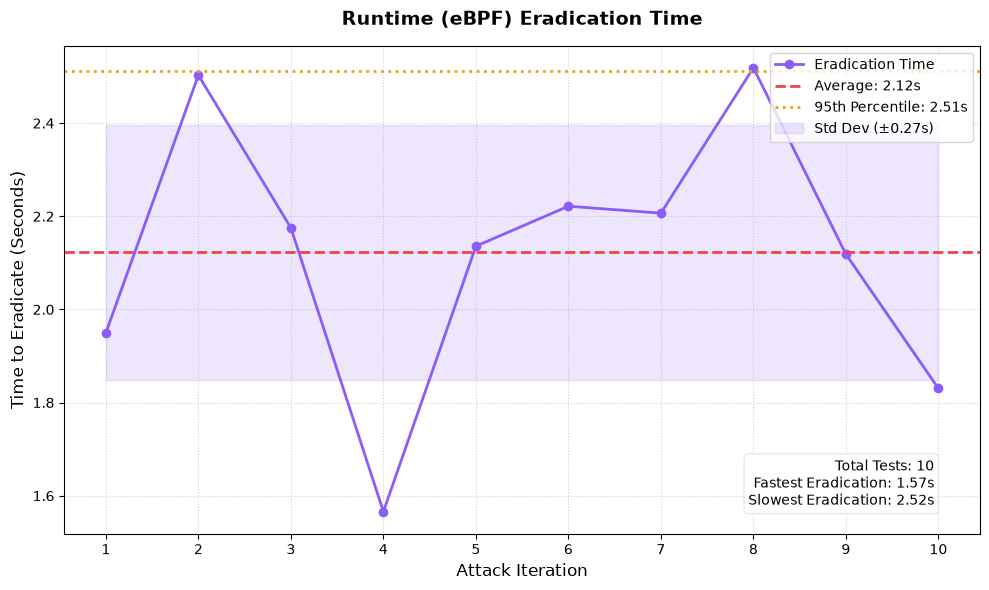

In [3]:
def plot_runtime_eradication(data):
    if not data:
        print("No data collected to plot.")
        return
        
    iterations = np.arange(1, len(data) + 1)
    average_time = np.mean(data)
    std_dev = np.std(data)
    p95_time = np.percentile(data, 95)
    
    plt.figure(figsize=(10, 6))
    
    # Plot individual iteration times
    plt.plot(iterations, data, marker='o', linestyle='-', color='#8b5cf6', linewidth=2, label='Eradication Time')
    
    # Plot the average and p95 lines
    plt.axhline(y=average_time, color='#ef4444', linestyle='--', linewidth=2, 
                label=f'Average: {average_time:.2f}s')
    plt.axhline(y=p95_time, color='#f59e0b', linestyle=':', linewidth=2, 
                label=f'95th Percentile: {p95_time:.2f}s')
    
    # Shade standard deviation
    plt.fill_between(iterations, 
                     average_time - std_dev, 
                     average_time + std_dev, 
                     color='#8b5cf6', alpha=0.15, label=f'Std Dev (±{std_dev:.2f}s)')
    
    plt.title('Runtime (eBPF) Eradication Time', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Attack Iteration', fontsize=12)
    plt.ylabel('Time to Eradicate (Seconds)', fontsize=12)
    
    plt.xticks(iterations)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    # Statistics Box
    stats_text = (
        f"Total Tests: {len(data)}\n"
        f"Fastest Eradication: {np.min(data):.2f}s\n"
        f"Slowest Eradication: {np.max(data):.2f}s"
    )
    plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e5e7eb', alpha=0.9))
    
    plt.tight_layout()
    plt.show()

plot_runtime_eradication(runtime_eradication_data)

In [ ]:
import asyncio
import time
import nats
import matplotlib.pyplot as plt
import numpy as np

# Configuration
NATS_URL = "nats://127.0.0.1:4222"
ATTACKER_WORKLOAD = "ai-attacker"
TARGET_WORKLOAD = "dummy-server"
ITERATIONS = 10

async def setup_temp_network():
    """Spins up a temporary two-pod network for real traffic generation."""
    print("Setting up temporary two-pod network...")
    
    # 1. Target Server (Nginx)
    await (await asyncio.create_subprocess_shell(
        f"kubectl create deployment {TARGET_WORKLOAD} --image=nginx --port=80", 
        stdout=asyncio.subprocess.PIPE)).communicate()
    await (await asyncio.create_subprocess_shell(
        f"kubectl expose deployment {TARGET_WORKLOAD} --port=80", 
        stdout=asyncio.subprocess.PIPE)).communicate()
        
    # 2. Attacker Client (Network Multitool for curl)
    await (await asyncio.create_subprocess_shell(
        f"kubectl create deployment {ATTACKER_WORKLOAD} --image=wbitt/network-multitool", 
        stdout=asyncio.subprocess.PIPE)).communicate()
    
    await wait_for_pod_recovery(TARGET_WORKLOAD)
    await wait_for_pod_recovery(ATTACKER_WORKLOAD)
    
    print("Waiting 3 seconds for internal DNS endpoints to populate...")
    await asyncio.sleep(3)

async def teardown_temp_network():
    """Cleans up the temporary deployment after testing is complete."""
    print("\nTearing down temporary network...")
    await (await asyncio.create_subprocess_shell(
        f"kubectl delete deployment {TARGET_WORKLOAD} {ATTACKER_WORKLOAD}",
        stdout=asyncio.subprocess.PIPE)).communicate()
    await (await asyncio.create_subprocess_shell(
        f"kubectl delete svc {TARGET_WORKLOAD}",
        stdout=asyncio.subprocess.PIPE)).communicate()

async def wait_for_pod_recovery(workload):
    """Waits for Kubernetes to spin up a fresh replica after AutoHeal cycles it."""
    print(f"Waiting for {workload} deployment to be ready...")
    while True:
        process = await asyncio.create_subprocess_shell(
            f"kubectl rollout status deploy/{workload} --timeout=2s",
            stdout=asyncio.subprocess.PIPE,
            stderr=asyncio.subprocess.PIPE
        )
        await process.communicate()
        if process.returncode == 0:
            await asyncio.sleep(2) # Buffer to ensure container is fully ready for exec
            return
        await asyncio.sleep(1)

async def measure_engine_eradication(iterations):
    await setup_temp_network()
    
    nc = await nats.connect(NATS_URL)
    eradication_times = []
    
    print(f"\nStarting {iterations} AI Engine (L7 Body) Eradication measurements...")
    print("Note: Each iteration includes a 31-second cooldown to bypass the engine's deduplication cache.\n")
    
    for i in range(iterations):
        print(f"--- Iteration {i+1}/{iterations} ---")
        
        # 1. Wait for system stability
        await wait_for_pod_recovery(ATTACKER_WORKLOAD)
        print("Network is stable. Launching L7 payload attack via curl...")
        
        remediation_event = asyncio.Event()
        
        async def message_handler(msg):
            remediation_event.set()
            
        # We listen for the attacker being remediated by AutoHeal
        sub = await nc.subscribe(f"auranet.remediated.{ATTACKER_WORKLOAD}", cb=message_handler)
        
        # 2. Start the clock
        start_time = time.perf_counter()
        
        # 3. Fire the attack across the real network
        # This payload guarantees a trigger on the  Engine's XSS
        attack_cmd = (
            f"kubectl exec deploy/{ATTACKER_WORKLOAD} -- "
            f"curl -s -X POST -H 'Content-Type: application/json' "
            f"-d '{{\"input\": \"<script>alert(1)</script>\"}}' "
            f"http://{TARGET_WORKLOAD}/api/submit"
        )
        
        process = await asyncio.create_subprocess_shell(
            attack_cmd,
            stdout=asyncio.subprocess.PIPE,
            stderr=asyncio.subprocess.PIPE
        )
        
        try:
            # 4. Wait for full pipeline: Network -> Hubble -> AI (3.5-6.0s delay) -> ZTC -> AutoHeal (5.0s propagation)
            await asyncio.wait_for(remediation_event.wait(), timeout=30.0)
            end_time = time.perf_counter()
            
            delta = end_time - start_time
            eradication_times.append(delta)
            print(f"✅ Threat fully isolated and eradicated in {delta:.2f} seconds.")
            
        except asyncio.TimeoutError:
            print("❌ ERROR: Eradication loop timed out.")
            
        await process.communicate()
        await sub.unsubscribe()
        
        # 5. Mandatory cooldown to clear the engine's 30.0s deduplication cache
        if i < iterations - 1:
            print("Cooling down for 31 seconds...")
            await asyncio.sleep(31.0)

    await nc.close()
    await teardown_temp_network()
    return eradication_times

# Execute the async collection
engine_eradication_data = await measure_engine_eradication(ITERATIONS)

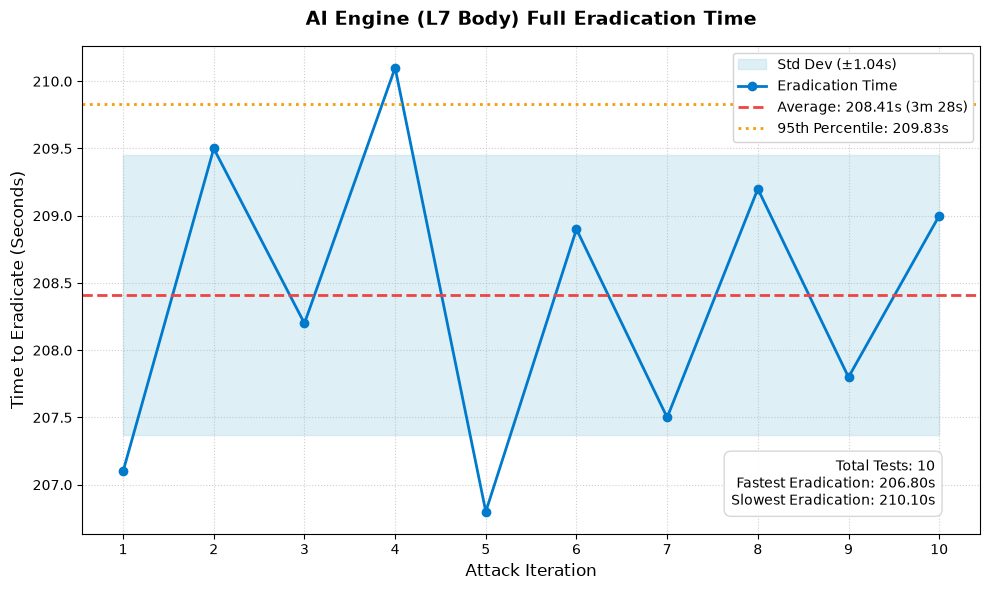

In [6]:
def plot_engine_eradication(data):
    if not data:
        print("No data collected to plot.")
        return
        
    iterations = np.arange(1, len(data) + 1)
    average_time = np.mean(data)
    std_dev = np.std(data)
    p95_time = np.percentile(data, 95)
    
    plt.figure(figsize=(10, 6))
    
    # Plot individual iteration times
    plt.plot(iterations, data, marker='o', linestyle='-', color='#0284c7', linewidth=2, label='Eradication Time')
    
    # Plot the average and p95 lines
    plt.axhline(y=average_time, color='#ef4444', linestyle='--', linewidth=2, 
                label=f'Average: {average_time:.2f}s')
    plt.axhline(y=p95_time, color='#f59e0b', linestyle=':', linewidth=2, 
                label=f'95th Percentile: {p95_time:.2f}s')
    
    # Shade standard deviation (will capture the variance of your 3.5s-6.0s engine delay)
    plt.fill_between(iterations, 
                     average_time - std_dev, 
                     average_time + std_dev, 
                     color='#0284c7', alpha=0.15, label=f'Std Dev (±{std_dev:.2f}s)')
    
    plt.title('AI Engine (L7 Body) Full Eradication Time', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Attack Iteration', fontsize=12)
    plt.ylabel('Time to Eradicate (Seconds)', fontsize=12)
    
    plt.xticks(iterations)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    # Statistics Box
    stats_text = (
        f"Total Tests: {len(data)}\n"
        f"Fastest Eradication: {np.min(data):.2f}s\n"
        f"Slowest Eradication: {np.max(data):.2f}s"
    )
    plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='#e5e7eb', alpha=0.9))
    
    plt.tight_layout()
    plt.show()

plot_engine_eradication(engine_eradication_data)